# Spotify Streaming Audit — Proyecto final

## Problema de negocio

Una plataforma de streaming tiene cerca de 2.000 canciones en su catálogo y no cuenta con un criterio objetivo para decidir qué canciones deberían entrar en playlists premium.

## Objetivo del notebook

Construir una auditoría del catálogo musical para identificar:

- canciones y segmentos de alto rendimiento,
- canciones en zona crítica,
- géneros y décadas con mayor potencial,
- relación entre atributos acústicos y `popularity`,
- señales externas de prestigio mediante Grammy Awards,
- segmentos musicales mediante clustering K-Means,
- y un modelo de regresión para estimar `popularity`.

## Entregables conectados a este notebook

- EDA reproducible.
- SQL con DuckDB.
- Modelo de regresión exportado con `joblib`.
- Clustering de vibes musicales con Silhouette Score.
- Tablas para dashboard en Tableau.
- Recomendaciones de negocio para pitch ejecutivo.

In [53]:
# ============================================
# INSTALACIÓN DE LIBRERÍAS NECESARIAS
# ============================================

%pip install pandas numpy matplotlib seaborn plotly duckdb scikit-learn joblib -q

Note: you may need to restart the kernel to use updated packages.


In [54]:
# ============================================
# IMPORTACIÓN DE LIBRERÍAS
# ============================================

import pandas as pd
import numpy as np
import re
import os
import unicodedata
import warnings
from pathlib import Path

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# SQL
import duckdb

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, silhouette_score
from sklearn.decomposition import PCA

# Exportación de modelos
import joblib

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

# Carpetas del proyecto
os.makedirs("data/processed", exist_ok=True)
os.makedirs("data/dashboard", exist_ok=True)
os.makedirs("models", exist_ok=True)
os.makedirs("visualizations", exist_ok=True)

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


# IMPORTACIÓN DE LIBRERÍAS
# ============================================

import pandas as pd
import numpy as np
import re
import os
import unicodedata
import warnings

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# SQL
import duckdb

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, silhouette_score
from sklearn.decomposition import PCA

# Exportación de modelos           
import joblib

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

# Carpetas del proyecto
os.makedirs("data/processed", exist_ok=True)
os.makedirs("data/dashboard", exist_ok=True)
os.makedirs("models", exist_ok=True)
os.makedirs("visualizations", exist_ok=True)

print("Librerías cargadas correctamente.")

## Carga de datasets limpios desde GitHub

Los datasets utilizados en este proyecto ya se encuentran limpios y disponibles en el repositorio oficial del proyecto.

Carpeta del repositorio:

`data/processed/`

Archivos utilizados:

- `spotify_2000_clean.csv`
- `grammy_awards_clean_final.csv`

Para que cualquier persona pueda ejecutar este notebook sin depender de rutas locales, los archivos se cargan directamente desde GitHub usando enlaces `raw`.

In [55]:
# ============================================
# RUTAS DE DATASETS LIMPIOS DESDE GITHUB
# ============================================

PATH_SPOTIFY = "https://raw.githubusercontent.com/isaacnhf-oss/Spotify-Streaming-Audit-/main/data/processed/spotify_2000_clean.csv"
PATH_GRAMMY = "https://raw.githubusercontent.com/isaacnhf-oss/Spotify-Streaming-Audit-/main/data/processed/grammy_awards_clean_final.csv"

print("Ruta Spotify:")
print(PATH_SPOTIFY)

print()
print("Ruta Grammy:")
print(PATH_GRAMMY)

Ruta Spotify:
https://raw.githubusercontent.com/isaacnhf-oss/Spotify-Streaming-Audit-/main/data/processed/spotify_2000_clean.csv

Ruta Grammy:
https://raw.githubusercontent.com/isaacnhf-oss/Spotify-Streaming-Audit-/main/data/processed/grammy_awards_clean_final.csv


In [56]:
# ============================================
# CARGA DE DATASETS LIMPIOS
# ============================================

spotify = pd.read_csv(PATH_SPOTIFY)
grammy = pd.read_csv(PATH_GRAMMY)

print("Dataset Spotify:", spotify.shape)
print("Dataset Grammy:", grammy.shape)

display(spotify.head())
display(grammy.head())

Dataset Spotify: (1994, 15)
Dataset Grammy: (4810, 10)


,index,title,artist,top_genre,year,beats_per_minute_bpm,energy,danceability,loudness_db,liveness,valence,length_duration,acousticness,speechiness,popularity
0,1,sunrise,norah jones,adult standards,2004,157,30,53,-14,11,68,201,94,3,71
1,2,black night,deep purple,album rock,2000,135,79,50,-11,17,81,207,17,7,39
2,3,clint eastwood,gorillaz,alternative hip hop,2001,168,69,66,-9,7,52,341,2,17,69
3,4,the pretender,foo fighters,alternative metal,2007,173,96,43,-4,3,37,269,0,4,76
4,5,waitin' on a sunny day,bruce springsteen,classic rock,2002,106,82,58,-5,10,87,256,1,3,59


,year,title,published_at,updated_at,category,nominee,artist,workers,img,winner
0,2019,62nd Annual GRAMMY Awards (2019),2020-05-19 12:10:28+00:00,2020-05-19 12:10:28+00:00,Record Of The Year,Bad Guy,Billie Eilish,"Finneas O'Connell, producer; Rob Kinelski & Fi...",https://www.grammy.com/sites/com/files/styles/...,True
1,2019,62nd Annual GRAMMY Awards (2019),2020-05-19 12:10:28+00:00,2020-05-19 12:10:28+00:00,Record Of The Year,"Hey, Ma",Bon Iver,"BJ Burton, Brad Cook, Chris Messina & Justin V...",https://www.grammy.com/sites/com/files/styles/...,True
2,2019,62nd Annual GRAMMY Awards (2019),2020-05-19 12:10:28+00:00,2020-05-19 12:10:28+00:00,Record Of The Year,7 rings,Ariana Grande,"Charles Anderson, Tommy Brown, Michael Foster ...",https://www.grammy.com/sites/com/files/styles/...,True
3,2019,62nd Annual GRAMMY Awards (2019),2020-05-19 12:10:28+00:00,2020-05-19 12:10:28+00:00,Record Of The Year,Hard Place,H.E.R.,"Rodney “Darkchild” Jerkins, producer; Joseph H...",https://www.grammy.com/sites/com/files/styles/...,True
4,2019,62nd Annual GRAMMY Awards (2019),2020-05-19 12:10:28+00:00,2020-05-19 12:10:28+00:00,Record Of The Year,Talk,Khalid,"Disclosure & Denis Kosiak, producers; Ingmar C...",https://www.grammy.com/sites/com/files/styles/...,True


### Validación de carga

Los datasets fueron cargados directamente desde GitHub.

Esto permite que el notebook sea reproducible para cualquier persona que tenga conexión a internet, sin necesidad de descargar manualmente los archivos ni configurar rutas locales en su computador.

## Validación inicial de los datasets

Antes de realizar el análisis exploratorio, revisamos:

- columnas disponibles,
- tipos de datos,
- valores nulos,
- duplicados,
- dimensiones de cada dataset.

Esta validación asegura que el notebook sea reproducible y que pueda ejecutarse de arriba hacia abajo sin errores.

In [57]:
print("Columnas Spotify:")
print(spotify.columns)

print("\nColumnas Grammy:")
print(grammy.columns)

Columnas Spotify:
Index(['index', 'title', 'artist', 'top_genre', 'year', 'beats_per_minute_bpm',
       'energy', 'danceability', 'loudness_db', 'liveness', 'valence',
       'length_duration', 'acousticness', 'speechiness', 'popularity'],
      dtype='object')

Columnas Grammy:
Index(['year', 'title', 'published_at', 'updated_at', 'category', 'nominee',
       'artist', 'workers', 'img', 'winner'],
      dtype='object')


In [58]:
# ============================================
# INFORMACIÓN GENERAL DE LOS DATASETS
# ============================================

print("Información Spotify")
spotify.info()

print()
print("Información Grammy")
grammy.info()

Información Spotify
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1994 entries, 0 to 1993
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   index                 1994 non-null   int64 
 1   title                 1994 non-null   object
 2   artist                1994 non-null   object
 3   top_genre             1994 non-null   object
 4   year                  1994 non-null   int64 
 5   beats_per_minute_bpm  1994 non-null   int64 
 6   energy                1994 non-null   int64 
 7   danceability          1994 non-null   int64 
 8   loudness_db           1994 non-null   int64 
 9   liveness              1994 non-null   int64 
 10  valence               1994 non-null   int64 
 11  length_duration       1994 non-null   int64 
 12  acousticness          1994 non-null   int64 
 13  speechiness           1994 non-null   int64 
 14  popularity            1994 non-null   int64 
dtypes: int64(12), obje

In [59]:
# ============================================
# REVISIÓN DE NULOS Y DUPLICADOS
# ============================================

print("Nulos Spotify:")
display(spotify.isnull().sum())

print()
print("Nulos Grammy:")
display(grammy.isnull().sum())

print()
print("Duplicados Spotify:", spotify.duplicated().sum())
print("Duplicados Grammy:", grammy.duplicated().sum())

Nulos Spotify:


index                   0
title                   0
artist                  0
top_genre               0
year                    0
beats_per_minute_bpm    0
energy                  0
danceability            0
loudness_db             0
liveness                0
valence                 0
length_duration         0
acousticness            0
speechiness             0
popularity              0
dtype: int64


Nulos Grammy:


year               0
title              0
published_at       0
updated_at         0
category           0
nominee            6
artist          1840
workers         2190
img             1367
winner             0
dtype: int64


Duplicados Spotify: 0
Duplicados Grammy: 0


### Hallazgo de validación inicial

El dataset de Spotify contiene variables musicales, año, género, artista y `popularity`, que será la métrica principal para evaluar rendimiento.

El dataset Grammy Awards se usará como fuente complementaria para incorporar una señal externa de reconocimiento de la industria musical.

A partir de este punto, el análisis se enfoca en transformar los datos en criterios para decidir qué canciones o segmentos deberían priorizarse en playlists premium.

# 1. KPIs principales del catálogo

Calculamos KPIs directamente conectados al problema de negocio:

- Popularity promedio del catálogo.
- Porcentaje de canciones en zona crítica.
- Porcentaje de canciones con potencial premium.
- Género con mayor rendimiento promedio.
- Cantidad total de canciones analizadas.

Estos KPIs permiten transformar el dataset en una lectura ejecutiva del catálogo.

In [60]:
# ============================================
# KPIS PRINCIPALES
# ============================================

total_canciones = len(spotify)
popularity_promedio = spotify["popularity"].mean()

canciones_zona_critica = (spotify["popularity"] <= 49).sum()
tasa_zona_critica = canciones_zona_critica / total_canciones * 100

canciones_premium = (spotify["popularity"] >= 72).sum()
tasa_premium = canciones_premium / total_canciones * 100

genero_top = (
    spotify.groupby("top_genre")
    .agg(
        total_canciones=("title", "count"),
        popularity_promedio=("popularity", "mean")
    )
    .query("total_canciones >= 20")
    .sort_values("popularity_promedio", ascending=False)
    .head(1)
)

print("=" * 80)
print("KPIS PRINCIPALES DEL CATÁLOGO")
print("=" * 80)
print(f"Total de canciones: {total_canciones}")
print(f"Popularity promedio del catálogo: {popularity_promedio:.2f}")
print(f"Canciones en zona crítica (Popularity <= 49): {canciones_zona_critica} ({tasa_zona_critica:.1f}%)")
print(f"Canciones con potencial premium (Popularity >= 72): {canciones_premium} ({tasa_premium:.1f}%)")
print("=" * 80)

display(genero_top)

KPIS PRINCIPALES DEL CATÁLOGO
Total de canciones: 1994
Popularity promedio del catálogo: 59.53
Canciones en zona crítica (Popularity <= 49): 499 (25.0%)
Canciones con potencial premium (Popularity >= 72): 458 (23.0%)


,total_canciones,popularity_promedio
top_genre,,
modern rock,49,68.591837


### Hallazgo inicial

El catálogo no debe tratarse como una lista homogénea. Existen canciones con alto potencial, canciones de rendimiento medio y canciones en zona crítica.

### Decisión de negocio

La plataforma necesita criterios objetivos para decidir qué canciones entran a playlists premium. `Popularity` será el primer criterio, pero se complementará con género, década, atributos acústicos, clusters e historial Grammy del artista.

# 2. Distribución del Popularity Score

Esta sección incorpora uno de los aportes útiles del EDA separado: analizar la distribución con histograma y boxplot.

Responde:

**¿Cómo se distribuye el rendimiento general del catálogo?**

In [61]:
# ============================================
# KPIS PRINCIPALES
# ============================================

total_canciones = len(spotify)
popularity_promedio = spotify["popularity"].mean()

canciones_zona_critica = (spotify["popularity"] <= 49).sum()
tasa_zona_critica = canciones_zona_critica / total_canciones * 100

canciones_premium = (spotify["popularity"] >= 72).sum()
tasa_premium = canciones_premium / total_canciones * 100

genero_top = (
    spotify.groupby("top_genre")
    .agg(
        total_canciones=("title", "count"),
        popularity_promedio=("popularity", "mean")
    )
    .query("total_canciones >= 20")
    .sort_values("popularity_promedio", ascending=False)
    .head(1)
)

print("=" * 80)
print("KPIS PRINCIPALES DEL CATÁLOGO")
print("=" * 80)
print(f"Total de canciones: {total_canciones}")
print(f"Popularity promedio del catálogo: {popularity_promedio:.2f}")
print(f"Canciones en zona crítica (Popularity <= 49): {canciones_zona_critica} ({tasa_zona_critica:.1f}%)")
print(f"Canciones con potencial premium (Popularity >= 72): {canciones_premium} ({tasa_premium:.1f}%)")
print("=" * 80)

display(genero_top)

KPIS PRINCIPALES DEL CATÁLOGO
Total de canciones: 1994
Popularity promedio del catálogo: 59.53
Canciones en zona crítica (Popularity <= 49): 499 (25.0%)
Canciones con potencial premium (Popularity >= 72): 458 (23.0%)


,total_canciones,popularity_promedio
top_genre,,
modern rock,49,68.591837


### Hallazgo inicial

El catálogo no debe tratarse como una lista homogénea. Existen canciones con alto potencial, canciones de rendimiento medio y canciones en zona crítica.

### Decisión de negocio

La plataforma necesita criterios objetivos para decidir qué canciones entran a playlists premium. `Popularity` será el primer criterio, pero se complementará con género, década, atributos acústicos, clusters e historial Grammy del artista.

# 2. Distribución del Popularity Score

Esta sección incorpora uno de los aportes útiles del EDA separado: analizar la distribución con histograma y boxplot.

Responde:

**¿Cómo se distribuye el rendimiento general del catálogo?**

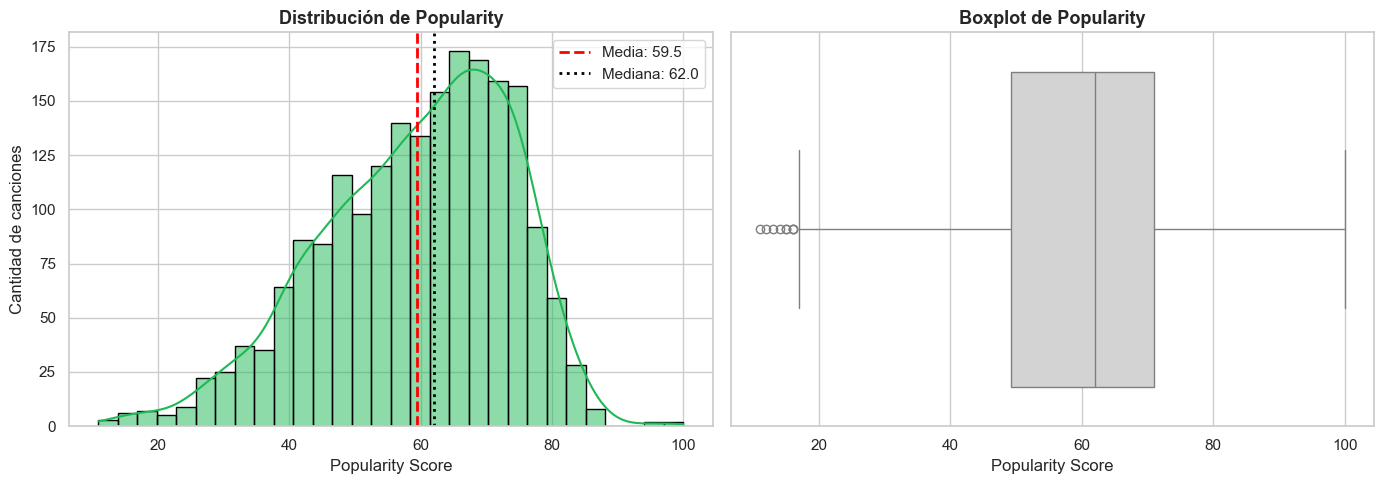

count    1994.00
mean       59.53
std        14.35
min        11.00
25%        49.25
50%        62.00
75%        71.00
max       100.00
Name: popularity, dtype: float64

In [62]:
# ============================================
# DISTRIBUCIÓN DE POPULARITY: HISTOGRAMA + BOXPLOT
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    spotify["popularity"],
    bins=30,
    kde=True,
    color="#1DB954",
    edgecolor="black",
    ax=axes[0]
)

axes[0].axvline(
    spotify["popularity"].mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Media: {spotify['popularity'].mean():.1f}"
)

axes[0].axvline(
    spotify["popularity"].median(),
    color="black",
    linestyle=":",
    linewidth=2,
    label=f"Mediana: {spotify['popularity'].median():.1f}"
)

axes[0].set_title("Distribución de Popularity", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Popularity Score")
axes[0].set_ylabel("Cantidad de canciones")
axes[0].legend()

sns.boxplot(
    x=spotify["popularity"],
    color="lightgray",
    ax=axes[1]
)

axes[1].set_title("Boxplot de Popularity", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Popularity Score")

plt.tight_layout()
plt.show()

spotify["popularity"].describe().round(2)

### Hallazgo

El catálogo presenta una distribución amplia de Popularity. Esto confirma que existen canciones de bajo rendimiento, canciones de rendimiento medio y canciones con potencial premium.

### Decisión de negocio

La plataforma no debería construir playlists premium de forma aleatoria. El primer filtro debe ser el rendimiento observado mediante `popularity`, y luego se deben incorporar otros criterios para mejorar la selección.

# 3. Segmentación por nivel de rendimiento

Creamos tres segmentos:

- `zona_critica`: canciones con `popularity <= 49`.
- `rendimiento_medio`: canciones entre 50 y 71.
- `potencial_premium`: canciones con `popularity >= 72`.

Esta segmentación convierte el análisis en una decisión de negocio concreta.

In [63]:
def segmentar_popularity(valor):
    if valor <= 49:
        return "zona_critica"
    elif valor >= 72:
        return "potencial_premium"
    else:
        return "rendimiento_medio"

spotify["segmento_popularity"] = spotify["popularity"].apply(segmentar_popularity)

segmentos = (
    spotify.groupby("segmento_popularity")
    .agg(
        total_canciones=("title", "count"),
        popularity_promedio=("popularity", "mean"),
        popularity_min=("popularity", "min"),
        popularity_max=("popularity", "max")
    )
    .reset_index()
)

segmentos["porcentaje_catalogo"] = segmentos["total_canciones"] / total_canciones * 100

display(segmentos)

,segmento_popularity,total_canciones,popularity_promedio,popularity_min,popularity_max,porcentaje_catalogo
0,potencial_premium,458,76.591703,72,100,22.968907
1,rendimiento_medio,1037,61.470588,50,71,52.006018
2,zona_critica,499,39.823647,11,49,25.025075


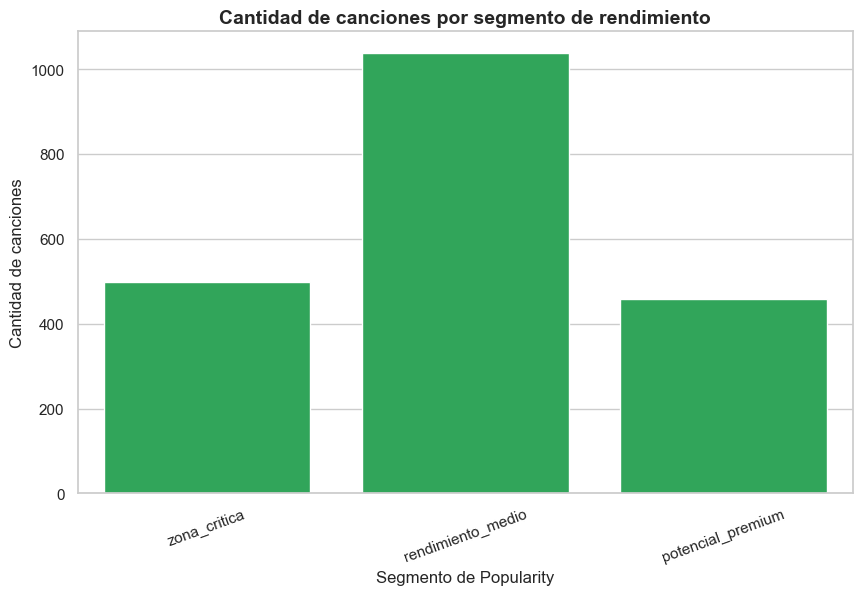

In [64]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=segmentos.sort_values("popularity_promedio"),
    x="segmento_popularity",
    y="total_canciones",
    color="#1DB954"
)

plt.title("Cantidad de canciones por segmento de rendimiento", fontsize=14, fontweight="bold")
plt.xlabel("Segmento de Popularity")
plt.ylabel("Cantidad de canciones")
plt.xticks(rotation=20)
plt.show()

### Hallazgo

La segmentación permite separar canciones candidatas a playlists premium de canciones que podrían perjudicar la experiencia del usuario si se priorizan sin criterio.

### Decisión de negocio

Las canciones de `potencial_premium` deben ser candidatas iniciales. Las canciones en `zona_critica` no deberían priorizarse, salvo que respondan a una estrategia de nicho.

# 4. Análisis por cuartiles de Popularity

Los cuartiles permiten ordenar el catálogo en cuatro niveles de rendimiento.

Esta sección responde:

**¿Qué diferencia existe entre el 25% más popular y el 25% menos popular del catálogo?**

In [65]:
spotify["popularity_quartile"] = pd.qcut(
    spotify["popularity"],
    q=4,
    labels=["Q1_bajo", "Q2_medio_bajo", "Q3_medio_alto", "Q4_alto"]
)

quartile_summary = (
    spotify.groupby("popularity_quartile", observed=False)
    .agg(
        total_canciones=("title", "count"),
        popularity_promedio=("popularity", "mean"),
        popularity_min=("popularity", "min"),
        popularity_max=("popularity", "max"),
        energy_promedio=("energy", "mean"),
        danceability_promedio=("danceability", "mean"),
        valence_promedio=("valence", "mean"),
        acousticness_promedio=("acousticness", "mean")
    )
    .reset_index()
)

display(quartile_summary)

,popularity_quartile,total_canciones,popularity_promedio,popularity_min,popularity_max,energy_promedio,danceability_promedio,valence_promedio,acousticness_promedio
0,Q1_bajo,499,39.823647,11,49,57.016032,51.282565,47.142285,32.358717
1,Q2_medio_bajo,540,56.411111,50,62,58.890741,51.827778,47.033333,28.818519
2,Q3_medio_alto,497,66.967807,63,71,59.895372,53.555332,51.678068,29.555332
3,Q4_alto,458,76.591703,72,100,63.277293,56.687773,52.216157,24.334061


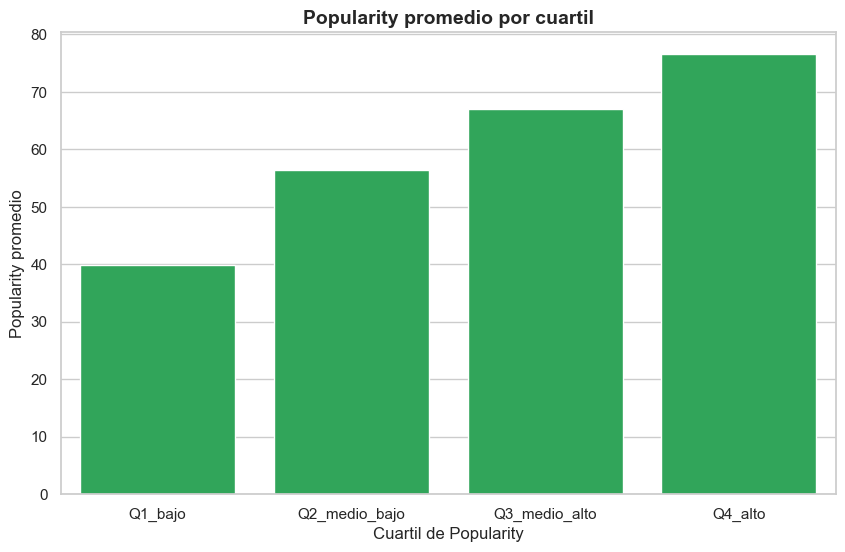

In [66]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=quartile_summary,
    x="popularity_quartile",
    y="popularity_promedio",
    color="#1DB954"
)

plt.title("Popularity promedio por cuartil", fontsize=14, fontweight="bold")
plt.xlabel("Cuartil de Popularity")
plt.ylabel("Popularity promedio")
plt.show()

### Hallazgo

El cuartil superior (`Q4_alto`) representa el benchmark inicial para playlists premium.

### Decisión de negocio

La plataforma puede usar el cuartil superior como criterio objetivo para construir una primera lista de canciones candidatas a playlists premium.

# 5. Perfil acústico y correlaciones con Popularity

Analizamos las variables acústicas para responder:

**¿Se puede explicar la Popularity usando solo características musicales?**

También revisamos relaciones entre variables acústicas, como `energy` y `loudness_db`, que ayudan a construir clusters de vibes musicales.

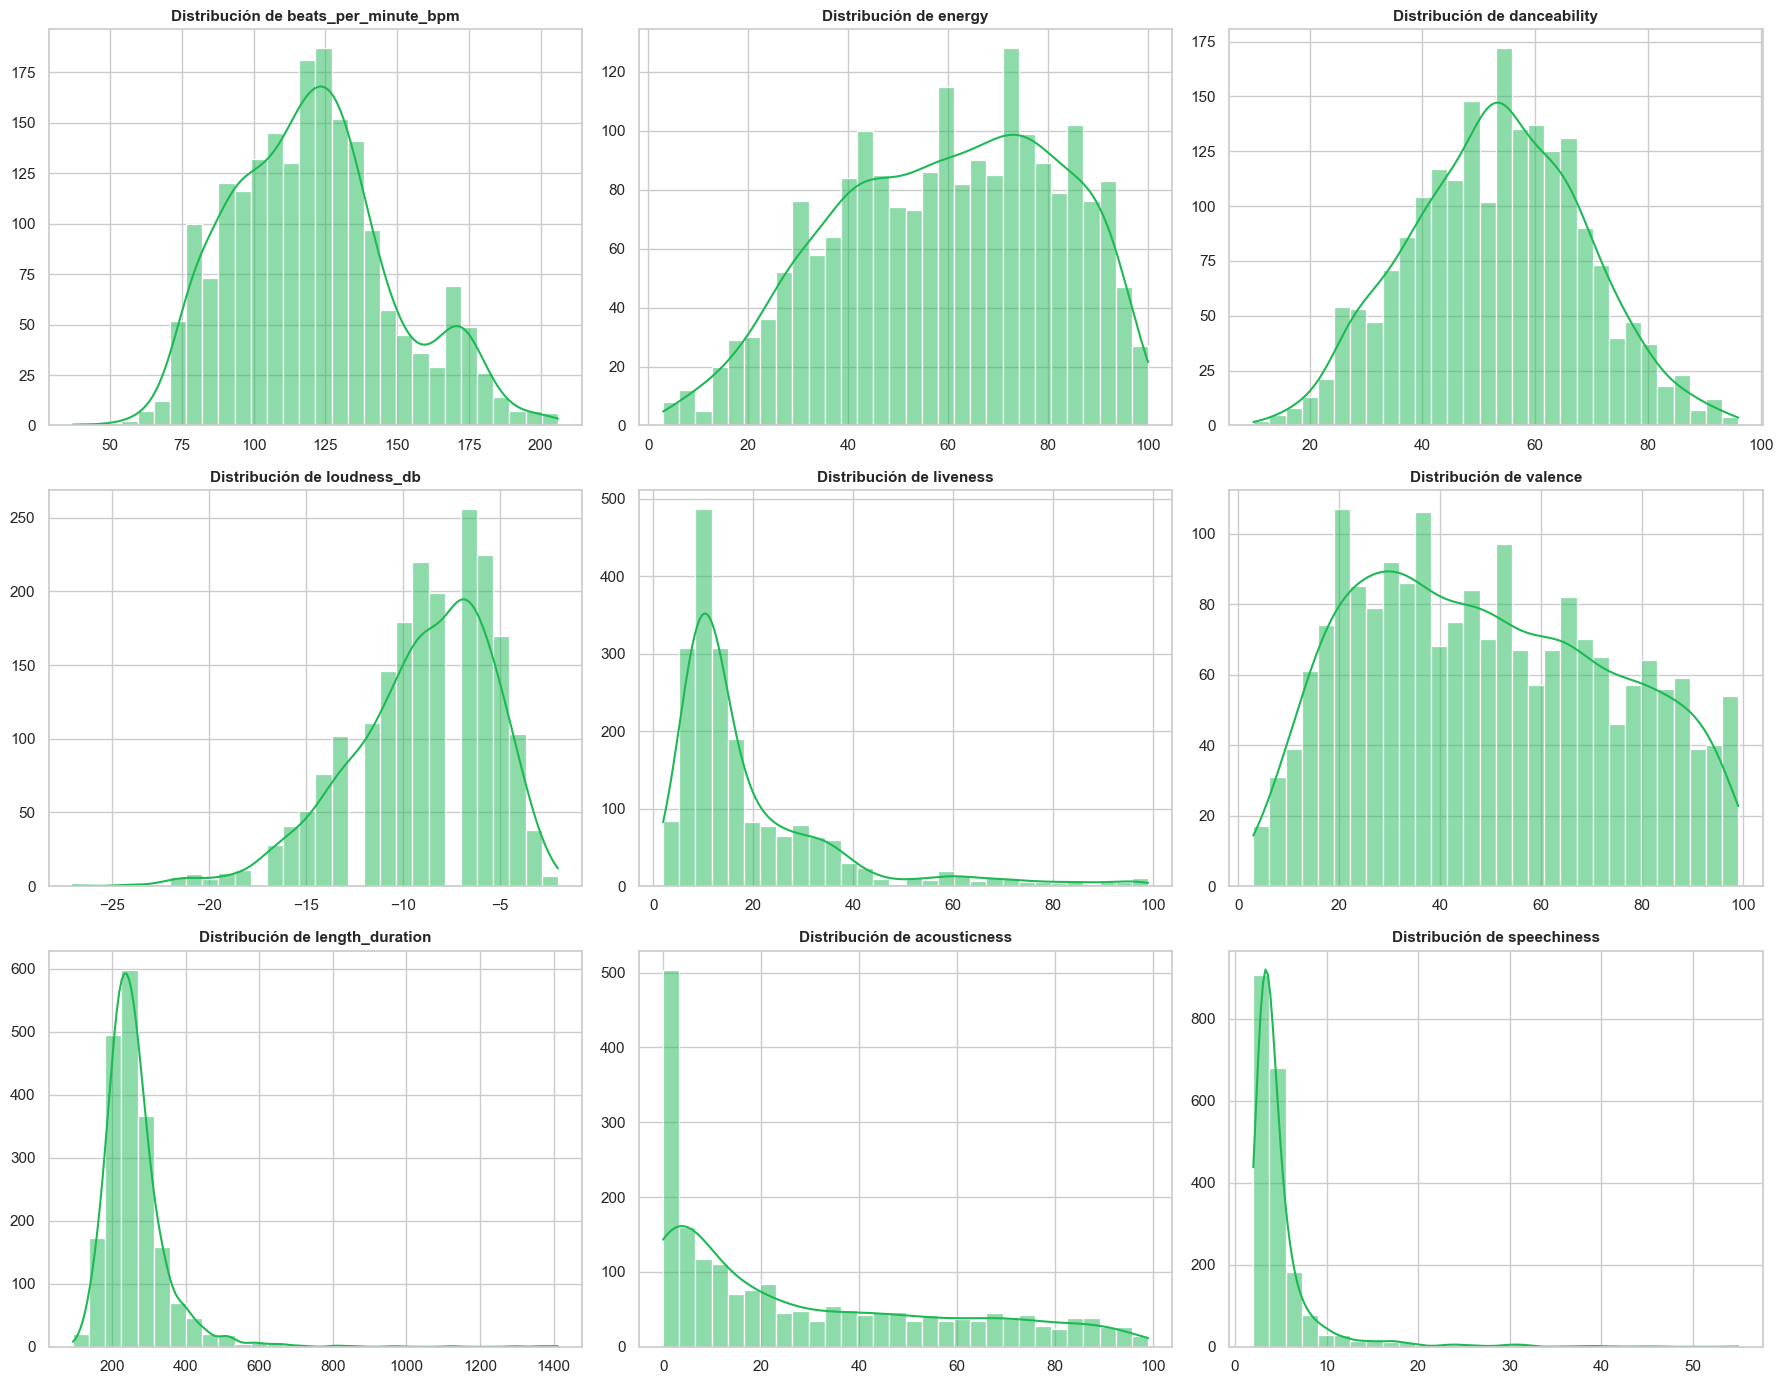

In [67]:
# ============================================
# DISTRIBUCIÓN DE VARIABLES ACÚSTICAS
# ============================================

acoustic_parameters = [
    "beats_per_minute_bpm",
    "energy",
    "danceability",
    "loudness_db",
    "liveness",
    "valence",
    "length_duration",
    "acousticness",
    "speechiness"
]

plt.figure(figsize=(18, 14))

for i, col in enumerate(acoustic_parameters):
    plt.subplot(3, 3, i + 1)
    sns.histplot(data=spotify, x=col, kde=True, color="#1DB954", bins=30)
    plt.title(f"Distribución de {col}", fontsize=11, fontweight="bold")
    plt.xlabel("")
    plt.ylabel("")

plt.tight_layout()
plt.show()

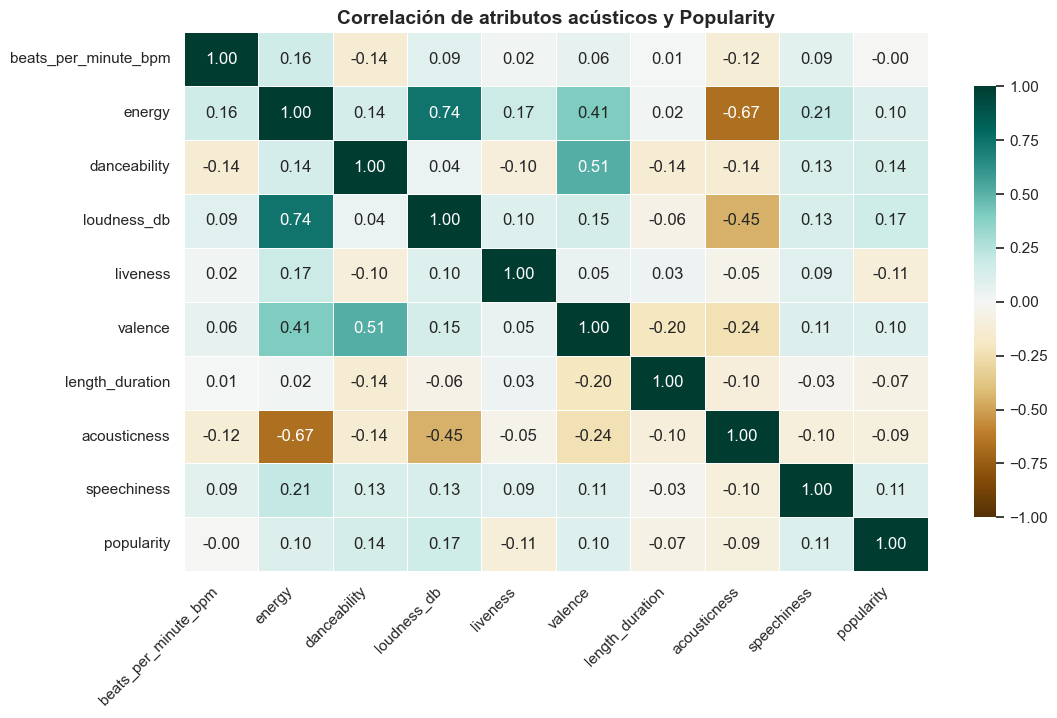

loudness_db             0.165527
danceability            0.144344
speechiness             0.111689
energy                  0.103393
valence                 0.095911
beats_per_minute_bpm   -0.003181
length_duration        -0.065403
acousticness           -0.087604
liveness               -0.111978
Name: popularity, dtype: float64

In [68]:
# ============================================
# MATRIZ DE CORRELACIÓN
# ============================================

columns_corr = acoustic_parameters + ["popularity"]
matriz_corr = spotify[columns_corr].corr()

plt.figure(figsize=(12, 7))

sns.heatmap(
    matriz_corr,
    cmap="BrBG",
    vmax=1,
    vmin=-1,
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlación de atributos acústicos y Popularity", fontsize=14, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.show()

correlation_with_popularity = (
    matriz_corr["popularity"]
    .drop("popularity")
    .sort_values(ascending=False)
)

display(correlation_with_popularity)

### Hallazgo

Ningún atributo acústico individual muestra una correlación fuerte con `popularity`. Esto sugiere que el éxito comercial de una canción es multifactorial.

Sin embargo, sí existen relaciones importantes entre variables acústicas, especialmente entre `energy` y `loudness_db`. Estas relaciones son útiles para segmentar el catálogo por perfiles musicales.

### Decisión de negocio

Los atributos acústicos no deben usarse de forma aislada para decidir playlists premium. Son más útiles para construir clusters o vibes musicales que para explicar directamente la Popularity.

# 6. Análisis por género: Popularity, volumen y cola larga

Esta sección incorpora uno de los mejores aportes del EDA separado: la detección de cola larga por género.

Responde:

**¿Qué géneros vale la pena incluir en playlists premium?**

No basta con ordenar géneros por Popularity promedio, porque algunos géneros tienen muy pocas canciones y pueden generar conclusiones poco representativas.

In [69]:
# ============================================
# RESUMEN POR GÉNERO
# ============================================

genre_summary = (
    spotify.groupby("top_genre")
    .agg(
        total_canciones=("title", "count"),
        popularity_promedio=("popularity", "mean"),
        popularity_mediana=("popularity", "median"),
        popularity_std=("popularity", "std"),
        tasa_premium=("popularity", lambda x: (x >= 72).mean() * 100),
        tasa_zona_critica=("popularity", lambda x: (x <= 49).mean() * 100)
    )
    .reset_index()
)

genre_summary_filtrado = (
    genre_summary
    .query("total_canciones >= 20")
    .sort_values("popularity_promedio", ascending=False)
)

display(genre_summary_filtrado.head(15))

,top_genre,total_canciones,popularity_promedio,popularity_mediana,popularity_std,tasa_premium,tasa_zona_critica
128,modern rock,49,68.591837,70.0,11.681393,48.979592,8.163265
71,dance pop,83,68.518072,72.0,12.610837,50.602410,9.638554
40,british invasion,36,68.083333,68.0,6.929750,27.777778,2.777778
135,permanent wave,38,67.657895,69.0,9.859215,34.210526,2.631579
136,pop,47,67.617021,69.0,14.534147,42.553191,12.765957
12,alternative rock,86,66.941860,68.0,9.402571,39.534884,3.488372
42,british soul,31,66.387097,67.0,8.102170,38.709677,6.451613
9,alternative metal,70,66.014286,67.0,9.537862,37.142857,5.714286
2,adult standards,123,62.577236,64.0,9.824700,20.325203,13.008130
61,classic rock,51,62.156863,65.0,11.846303,27.450980,17.647059


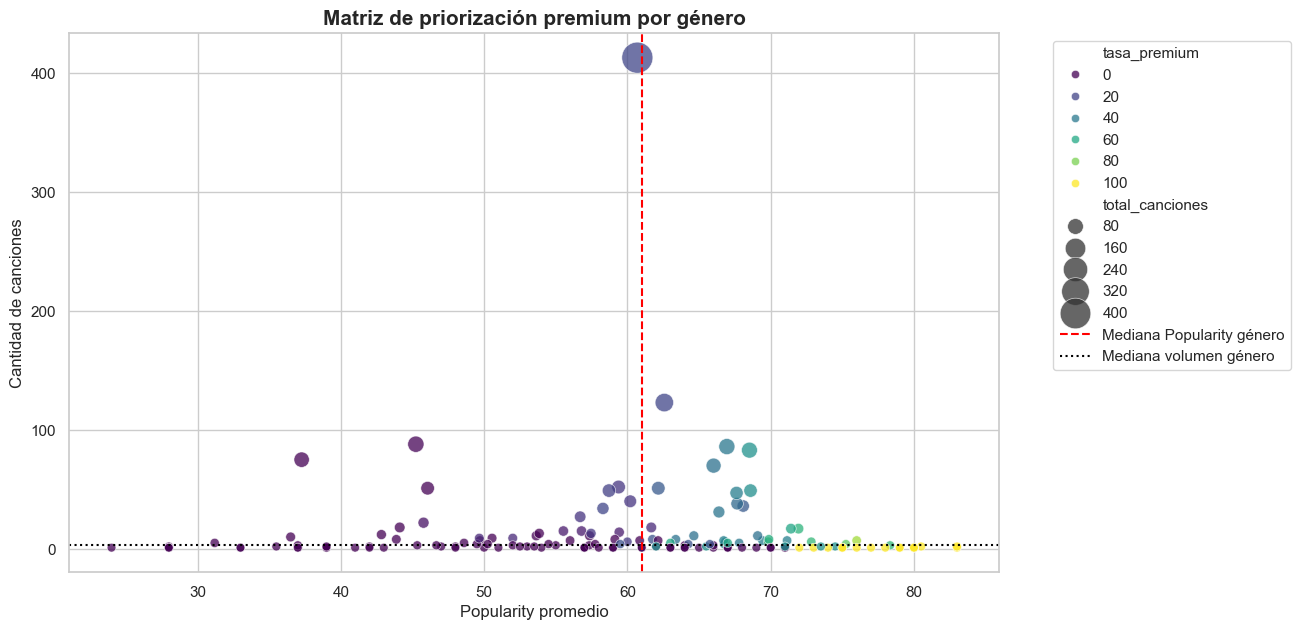

In [70]:
# ============================================
# MATRIZ DE PRIORIZACIÓN: POPULARITY VS VOLUMEN
# ============================================

plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=genre_summary,
    x="popularity_promedio",
    y="total_canciones",
    size="total_canciones",
    hue="tasa_premium",
    palette="viridis",
    sizes=(40, 500),
    alpha=0.75
)

plt.axvline(
    genre_summary["popularity_promedio"].median(),
    color="red",
    linestyle="--",
    label="Mediana Popularity género"
)

plt.axhline(
    genre_summary["total_canciones"].median(),
    color="black",
    linestyle=":",
    label="Mediana volumen género"
)

plt.title("Matriz de priorización premium por género", fontsize=15, fontweight="bold")
plt.xlabel("Popularity promedio")
plt.ylabel("Cantidad de canciones")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

Número de géneros existentes: 149
Géneros con menos de 5 canciones: 89


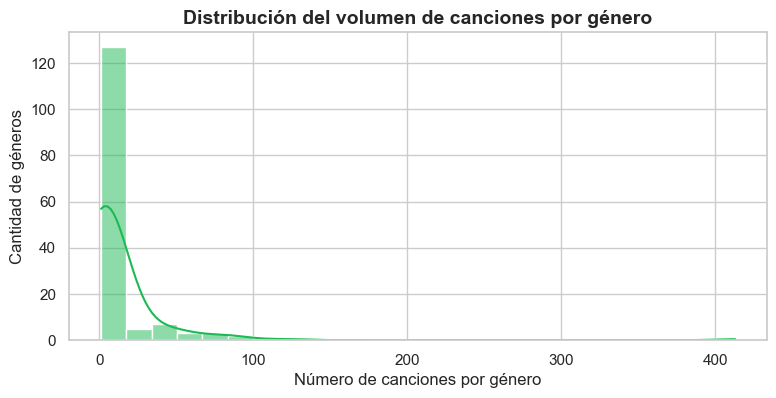

In [71]:
# ============================================
# COLA LARGA DE GÉNEROS
# ============================================

genre_count = spotify["top_genre"].value_counts()

print("Número de géneros existentes:", spotify["top_genre"].nunique())
print("Géneros con menos de 5 canciones:", (genre_count < 5).sum())

plt.figure(figsize=(9, 4))

sns.histplot(
    x=genre_count.values,
    bins=25,
    kde=True,
    color="#1DB954"
)

plt.title("Distribución del volumen de canciones por género", fontsize=14, fontweight="bold")
plt.xlabel("Número de canciones por género")
plt.ylabel("Cantidad de géneros")
plt.show()

### Hallazgo

El catálogo tiene una distribución de géneros tipo cola larga: pocos géneros concentran muchas canciones, mientras que muchos géneros tienen muy bajo volumen.

Esto significa que un ranking de géneros por Popularity promedio puede ser engañoso si no se considera el tamaño de muestra.

### Decisión de negocio

Para playlists premium, se deben priorizar géneros que combinen alta Popularity promedio, suficiente volumen, baja proporción de zona crítica y presencia de artistas con historial Grammy cuando aplique.

La matriz Popularity vs volumen debe ser una visual central del dashboard en Tableau.

## Cierre del EDA inicial

Hasta este punto ya se identificaron los criterios base para evaluar el catálogo:

- Popularity como métrica principal de rendimiento.
- Segmentos de rendimiento.
- Cuartiles para identificar benchmark premium.
- Atributos acústicos para entender perfiles musicales.
- Género y volumen para evitar decisiones basadas en muestras pequeñas.

A partir de la siguiente sección se incorporan análisis temporales, Grammy Awards, SQL, modelos predictivos, clustering y preparación para Tableau.

# 7. Análisis temporal: Popularity y géneros por década

Esta sección responde:

**¿Qué décadas y géneros funcionan mejor dentro del catálogo?**

El análisis temporal permite decidir si las playlists premium deben priorizar contenido reciente, histórico o una mezcla curada.

In [72]:
# ============================================
# POPULARITY POR DÉCADA
# ============================================

spotify["decade_num"] = (spotify["year"] // 10) * 10
spotify["decade"] = spotify["decade_num"].astype(str) + "s"

decade_summary = (
    spotify.groupby("decade")
    .agg(
        total_canciones=("title", "count"),
        popularity_promedio=("popularity", "mean"),
        popularity_mediana=("popularity", "median"),
        tasa_premium=("popularity", lambda x: (x >= 72).mean() * 100)
    )
    .reset_index()
    .sort_values("decade")
)

display(decade_summary)

,decade,total_canciones,popularity_promedio,popularity_mediana,tasa_premium
0,1950s,9,66.222222,66.0,22.222222
1,1960s,158,64.164557,67.0,27.848101
2,1970s,353,62.130312,64.0,22.096317
3,1980s,344,59.447674,60.0,19.476744
4,1990s,331,59.471299,61.0,20.543807
5,2000s,400,57.975000,58.0,22.000000
6,2010s,399,56.904762,59.0,27.819549


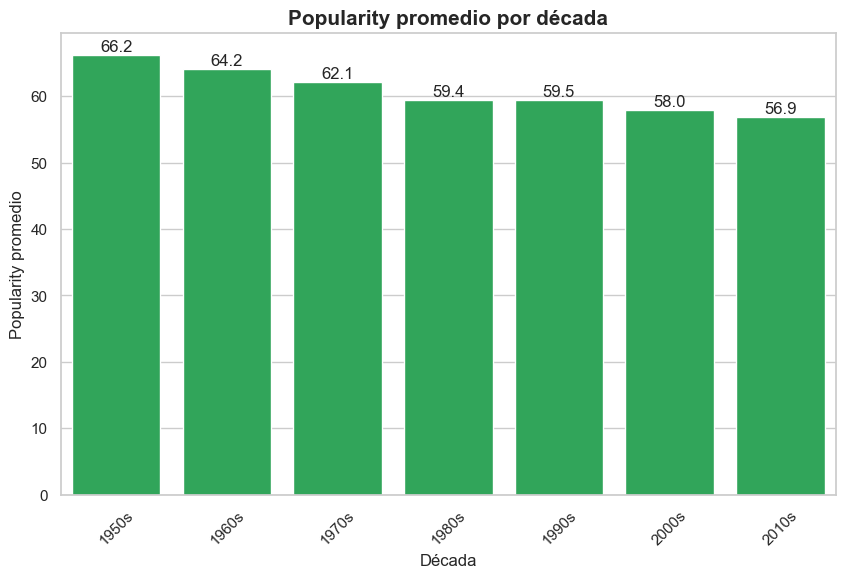

In [73]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=decade_summary,
    x="decade",
    y="popularity_promedio",
    color="#1DB954"
)

plt.title("Popularity promedio por década", fontsize=15, fontweight="bold")
plt.xlabel("Década")
plt.ylabel("Popularity promedio")
plt.xticks(rotation=45)

for index, row in decade_summary.iterrows():
    plt.text(
        index,
        row["popularity_promedio"] + 0.5,
        f"{row['popularity_promedio']:.1f}",
        ha="center"
    )

plt.show()

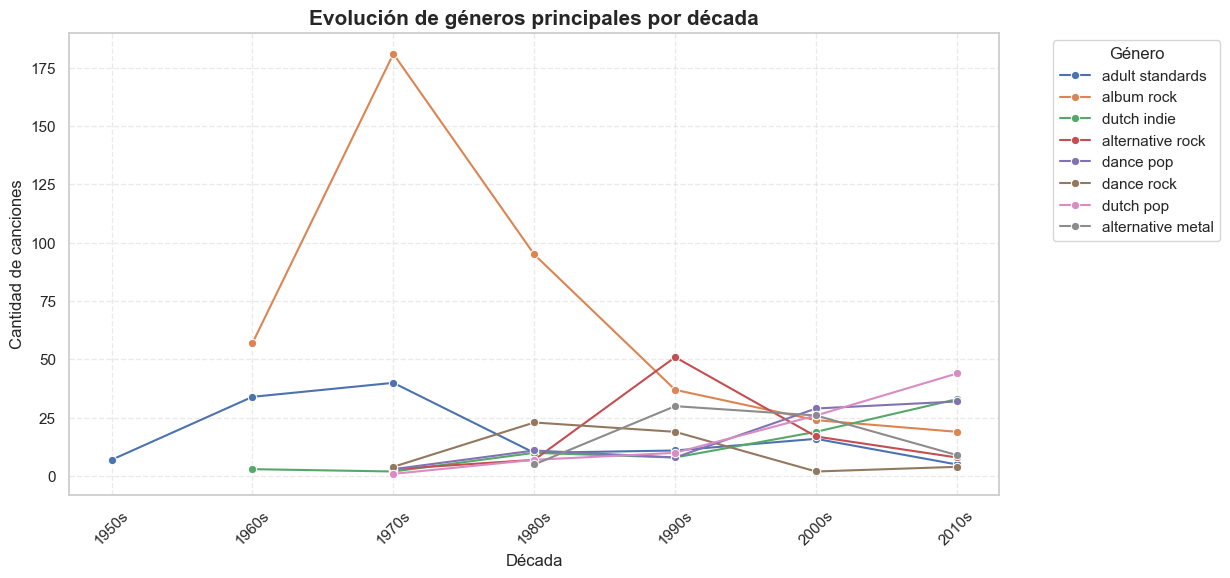

In [74]:
# ============================================
# EVOLUCIÓN DE GÉNEROS PRINCIPALES POR DÉCADA
# ============================================

top_genres_temporal = spotify["top_genre"].value_counts().head(8).index
spotify_temporal = spotify[spotify["top_genre"].isin(top_genres_temporal)].copy()

genre_decade = (
    spotify_temporal
    .groupby(["decade", "top_genre"])
    .size()
    .reset_index(name="total_canciones")
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=genre_decade,
    x="decade",
    y="total_canciones",
    hue="top_genre",
    marker="o"
)

plt.title("Evolución de géneros principales por década", fontsize=15, fontweight="bold")
plt.xlabel("Década")
plt.ylabel("Cantidad de canciones")
plt.xticks(rotation=45)
plt.legend(title="Género", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

### Hallazgo

La Popularity promedio varía por década y algunos géneros tienen una presencia claramente temporal.

Géneros históricos pueden funcionar como patrimonio musical, mientras que géneros más recientes pueden ayudar a sostener playlists premium orientadas a consumo actual.

### Decisión de negocio

El catálogo premium debería equilibrar:

- canciones contemporáneas de alto rendimiento,
- clásicos con permanencia histórica,
- y géneros con presencia fuerte en varias décadas.

# 8. Integración con Grammy Awards

El dataset Grammy Awards se utiliza como señal externa de reconocimiento de la industria musical.

El cruce principal se realiza a nivel de artista, no a nivel exacto de canción, porque los títulos pueden variar por versiones, colaboraciones, remixes o formatos editoriales.

Por lo tanto, las variables creadas indican si el artista tiene historial de nominaciones o premios Grammy, no que una canción específica haya ganado un Grammy.

In [75]:
# ============================================
# NORMALIZACIÓN DE TEXTO PARA CRUCE
# ============================================

def normalizar_texto(texto):
    if pd.isna(texto):
        return ""
    texto = str(texto).lower().strip()
    texto = unicodedata.normalize("NFKD", texto)
    texto = "".join([c for c in texto if not unicodedata.combining(c)])
    texto = re.sub(r"[^a-z0-9\s]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

spotify["artist_match"] = spotify["artist"].apply(normalizar_texto)
spotify["title_match"] = spotify["title"].apply(normalizar_texto)

grammy["artist_match"] = grammy["artist"].apply(normalizar_texto)
grammy["title_match"] = grammy["nominee"].apply(normalizar_texto)

display(spotify[["artist", "title", "artist_match", "title_match"]].head())
display(grammy[["artist", "nominee", "artist_match", "title_match"]].head())

,artist,title,artist_match,title_match
0,norah jones,sunrise,norah jones,sunrise
1,deep purple,black night,deep purple,black night
2,gorillaz,clint eastwood,gorillaz,clint eastwood
3,foo fighters,the pretender,foo fighters,the pretender
4,bruce springsteen,waitin' on a sunny day,bruce springsteen,waitin on a sunny day


,artist,nominee,artist_match,title_match
0,Billie Eilish,Bad Guy,billie eilish,bad guy
1,Bon Iver,"Hey, Ma",bon iver,hey ma
2,Ariana Grande,7 rings,ariana grande,7 rings
3,H.E.R.,Hard Place,h e r,hard place
4,Khalid,Talk,khalid,talk


## Cruce a nivel artista

El cruce se realiza a nivel de artista para identificar canciones interpretadas por artistas con historial Grammy.

Esta variable se utilizará como señal secundaria de prestigio, no como prueba de que una canción específica ganó un Grammy.

In [76]:
# ============================================
# CRUCE SPOTIFY + GRAMMY A NIVEL ARTISTA
# ============================================

grammy_artist_summary = (
    grammy[grammy["artist_match"] != ""]
    .groupby("artist_match")
    .agg(
        artist_grammy_nominations=("category", "count"),
        artist_grammy_wins=("winner", "sum")
    )
    .reset_index()
)

spotify_grammy = spotify.merge(
    grammy_artist_summary,
    on="artist_match",
    how="left"
)

spotify_grammy["artist_grammy_nominations"] = spotify_grammy["artist_grammy_nominations"].fillna(0).astype(int)
spotify_grammy["artist_grammy_wins"] = spotify_grammy["artist_grammy_wins"].fillna(0).astype(int)
spotify_grammy["artist_has_grammy_record"] = spotify_grammy["artist_grammy_nominations"] > 0
spotify_grammy["artist_has_grammy_win"] = spotify_grammy["artist_grammy_wins"] > 0

display(
    spotify_grammy[
        [
            "title",
            "artist",
            "popularity",
            "artist_grammy_nominations",
            "artist_grammy_wins",
            "artist_has_grammy_record"
        ]
    ].head()
)

,title,artist,popularity,artist_grammy_nominations,artist_grammy_wins,artist_has_grammy_record
0,sunrise,norah jones,71,5,5,True
1,black night,deep purple,39,0,0,False
2,clint eastwood,gorillaz,69,0,0,False
3,the pretender,foo fighters,76,10,10,True
4,waitin' on a sunny day,bruce springsteen,59,13,13,True


In [77]:
artist_grammy_comparison = (
    spotify_grammy.groupby("artist_has_grammy_record")
    .agg(
        total_canciones=("title", "count"),
        popularity_promedio=("popularity", "mean"),
        popularity_mediana=("popularity", "median"),
        tasa_premium=("popularity", lambda x: (x >= 72).mean() * 100),
        tasa_zona_critica=("popularity", lambda x: (x <= 49).mean() * 100)
    )
    .reset_index()
)

artist_grammy_comparison["grupo_grammy"] = artist_grammy_comparison["artist_has_grammy_record"].map({
    False: "Sin historial Grammy",
    True: "Con historial Grammy"
})

display(artist_grammy_comparison)

,artist_has_grammy_record,total_canciones,popularity_promedio,popularity_mediana,tasa_premium,tasa_zona_critica,grupo_grammy
0,False,1126,55.290409,56.0,16.429840,36.234458,Sin historial Grammy
1,True,868,65.021889,66.5,31.451613,10.483871,Con historial Grammy


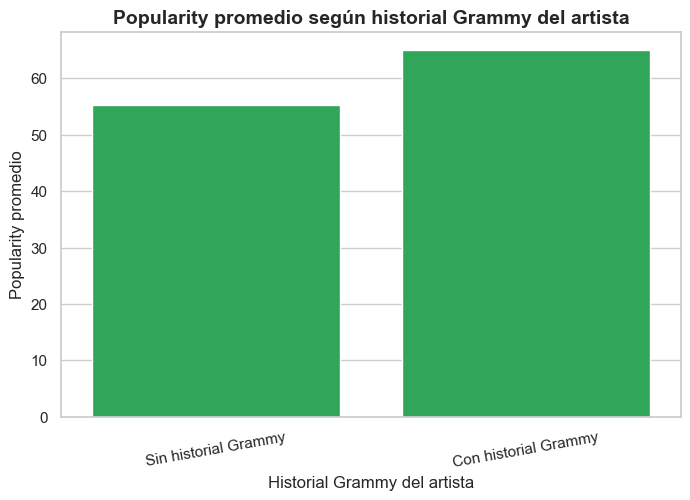

In [78]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=artist_grammy_comparison,
    x="grupo_grammy",
    y="popularity_promedio",
    color="#1DB954"
)

plt.title("Popularity promedio según historial Grammy del artista", fontsize=14, fontweight="bold")
plt.xlabel("Historial Grammy del artista")
plt.ylabel("Popularity promedio")
plt.xticks(rotation=10)
plt.show()

### Hallazgo Grammy

Las canciones de artistas con historial Grammy presentan una señal adicional de prestigio dentro del catálogo.

Esta señal no debe reemplazar `popularity`, pero puede ayudar a priorizar canciones cuando existen alternativas con rendimiento similar.

### Decisión de negocio

Usar historial Grammy como criterio secundario para reforzar playlists premium con valor reputacional.

In [79]:
genre_grammy_summary = (
    spotify_grammy
    .groupby("top_genre")
    .agg(
        total_canciones=("title", "count"),
        popularity_promedio=("popularity", "mean"),
        tasa_premium=("popularity", lambda x: (x >= 72).mean() * 100),
        porcentaje_artistas_grammy=("artist_has_grammy_record", lambda x: x.mean() * 100)
    )
    .reset_index()
    .query("total_canciones >= 20")
    .sort_values("popularity_promedio", ascending=False)
)

display(genre_grammy_summary.head(15))

,top_genre,total_canciones,popularity_promedio,tasa_premium,porcentaje_artistas_grammy
128,modern rock,49,68.591837,48.979592,77.551020
71,dance pop,83,68.518072,50.602410,53.012048
40,british invasion,36,68.083333,27.777778,100.000000
135,permanent wave,38,67.657895,34.210526,94.736842
136,pop,47,67.617021,42.553191,82.978723
12,alternative rock,86,66.941860,39.534884,65.116279
42,british soul,31,66.387097,38.709677,70.967742
9,alternative metal,70,66.014286,37.142857,51.428571
2,adult standards,123,62.577236,20.325203,71.544715
61,classic rock,51,62.156863,27.450980,64.705882


### Hallazgo

Algunos géneros combinan buen rendimiento promedio con presencia de artistas con historial Grammy.

### Decisión de negocio

Estos géneros pueden tener mayor valor para playlists premium porque combinan rendimiento en streaming y prestigio externo.

# 9. SQL con DuckDB

El proyecto exige mínimo 2 queries con DuckDB que respondan preguntas de negocio concretas.

Incluimos 3 consultas:

1. Segmentación por década.
2. Segmentación por cuartil de Popularity.
3. Géneros con mayor potencial premium.

Cada query responde una decisión de negocio y puede alimentar el dashboard en Tableau.

In [80]:
# ============================================
# CONEXIÓN DUCKDB
# ============================================

con = duckdb.connect()

con.register("spotify", spotify)
con.register("spotify_grammy", spotify_grammy)

print("Tablas registradas en DuckDB.")

Tablas registradas en DuckDB.


## Query 1 — Segmentación por década

**Pregunta de negocio:**  
¿Qué décadas tienen mejor rendimiento promedio?

**Decisión que responde:**  
Priorizar décadas para playlists premium temáticas.



In [81]:
query_decadas = """
SELECT
    decade,
    COUNT(*) AS total_canciones,
    ROUND(AVG(popularity), 2) AS popularity_promedio,
    ROUND(MEDIAN(popularity), 2) AS popularity_mediana,
    ROUND(100.0 * SUM(CASE WHEN popularity >= 72 THEN 1 ELSE 0 END) / COUNT(*), 2) AS tasa_premium_pct
FROM spotify
GROUP BY decade
ORDER BY decade;
"""

resultado_decadas = con.execute(query_decadas).df()
display(resultado_decadas)

,decade,total_canciones,popularity_promedio,popularity_mediana,tasa_premium_pct
0,1950s,9,66.22,66.0,22.22
1,1960s,158,64.16,67.0,27.85
2,1970s,353,62.13,64.0,22.10
3,1980s,344,59.45,60.0,19.48
4,1990s,331,59.47,61.0,20.54
5,2000s,400,57.98,58.0,22.00
6,2010s,399,56.90,59.0,27.82


## Query 2 — Segmentación por cuartil de Popularity

**Pregunta de negocio:**  
¿Qué caracteriza a las canciones del cuartil superior frente al resto del catálogo?

**Decisión que responde:**  
Definir criterios de selección para playlists premium usando el top 25% del catálogo.

In [82]:
query_cuartiles = """
SELECT
    popularity_quartile,
    COUNT(*) AS total_canciones,
    MIN(popularity) AS popularity_minima,
    MAX(popularity) AS popularity_maxima,
    ROUND(AVG(popularity), 2) AS popularity_promedio,
    ROUND(AVG(energy), 2) AS energy_promedio,
    ROUND(AVG(danceability), 2) AS danceability_promedio,
    ROUND(AVG(acousticness), 2) AS acousticness_promedio,
    ROUND(AVG(valence), 2) AS valence_promedio
FROM spotify
GROUP BY popularity_quartile
ORDER BY popularity_quartile;
"""

resultado_cuartiles = con.execute(query_cuartiles).df()
display(resultado_cuartiles)

,popularity_quartile,total_canciones,popularity_minima,popularity_maxima,popularity_promedio,energy_promedio,danceability_promedio,acousticness_promedio,valence_promedio
0,Q1_bajo,499,11,49,39.82,57.02,51.28,32.36,47.14
1,Q2_medio_bajo,540,50,62,56.41,58.89,51.83,28.82,47.03
2,Q3_medio_alto,497,63,71,66.97,59.90,53.56,29.56,51.68
3,Q4_alto,458,72,100,76.59,63.28,56.69,24.33,52.22


## Query 3 — Géneros con mayor potencial premium

**Pregunta de negocio:**  
¿Qué géneros tienen mejor rendimiento y volumen suficiente?

**Decisión que responde:**  
Priorizar géneros para playlists premium, recomendaciones y campañas.

In [83]:
query_generos = """
SELECT
    top_genre,
    COUNT(*) AS total_canciones,
    ROUND(AVG(popularity), 2) AS popularity_promedio,
    ROUND(100.0 * SUM(CASE WHEN popularity >= 72 THEN 1 ELSE 0 END) / COUNT(*), 2) AS tasa_premium_pct,
    ROUND(100.0 * SUM(CASE WHEN popularity <= 49 THEN 1 ELSE 0 END) / COUNT(*), 2) AS tasa_zona_critica_pct
FROM spotify
GROUP BY top_genre
HAVING COUNT(*) >= 20
ORDER BY popularity_promedio DESC
LIMIT 10;
"""

resultado_generos = con.execute(query_generos).df()
display(resultado_generos)

,top_genre,total_canciones,popularity_promedio,tasa_premium_pct,tasa_zona_critica_pct
0,modern rock,49,68.59,48.98,8.16
1,dance pop,83,68.52,50.60,9.64
2,british invasion,36,68.08,27.78,2.78
3,permanent wave,38,67.66,34.21,2.63
4,pop,47,67.62,42.55,12.77
5,alternative rock,86,66.94,39.53,3.49
6,british soul,31,66.39,38.71,6.45
7,alternative metal,70,66.01,37.14,5.71
8,adult standards,123,62.58,20.33,13.01
9,classic rock,51,62.16,27.45,17.65


# 10. Modelo de regresión para predecir Popularity

El proyecto exige entrenar y exportar un modelo capaz de predecir el `Popularity Score` a partir de atributos acústicos.

Se comparan tres algoritmos:

- Linear Regression.
- Ridge Regression.
- Random Forest Regressor.

Métricas documentadas:

- RMSE.
- MAE.
- R².

La decisión de negocio que responde esta sección es:

**¿Los atributos acústicos permiten anticipar qué canciones tienen mayor potencial de popularidad?**

In [84]:
# ============================================
# PREPARACIÓN DE FEATURES Y TARGET
# ============================================

model_features = [
    "beats_per_minute_bpm",
    "energy",
    "danceability",
    "loudness_db",
    "liveness",
    "valence",
    "length_duration",
    "acousticness",
    "speechiness"
]

X = spotify[model_features].copy()
y = spotify["popularity"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Tamaño X_train:", X_train.shape)
print("Tamaño X_test:", X_test.shape)

Tamaño X_train: (1595, 9)
Tamaño X_test: (399, 9)


In [85]:
# ============================================
# COMPARACIÓN DE MODELOS
# ============================================

models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "Ridge Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),
    "Random Forest": Pipeline([
        ("scaler", StandardScaler()),
        ("model", RandomForestRegressor(
            n_estimators=300,
            max_depth=8,
            random_state=42
        ))
    ])
}

model_results = []

for model_name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    model_results.append({
        "modelo": model_name,
        "rmse": rmse,
        "mae": mae,
        "r2": r2
    })

model_results_df = (
    pd.DataFrame(model_results)
    .sort_values("rmse")
    .reset_index(drop=True)
)

display(model_results_df)

,modelo,rmse,mae,r2
0,Random Forest,14.252832,11.526744,0.054340
1,Linear Regression,14.301113,11.600289,0.047923
2,Ridge Regression,14.301291,11.600368,0.047899


In [86]:
# ============================================
# EXPORTACIÓN DEL MEJOR MODELO CON JOBLIB
# ============================================

best_model_name = model_results_df.loc[0, "modelo"]
best_model = models[best_model_name]

best_rmse = model_results_df.loc[0, "rmse"]
best_mae = model_results_df.loc[0, "mae"]
best_r2 = model_results_df.loc[0, "r2"]

joblib.dump(best_model, "models/best_popularity_model.joblib")

print(f"Mejor modelo: {best_model_name}")
print(f"RMSE mejor modelo: {best_rmse:.3f}")
print(f"MAE mejor modelo: {best_mae:.3f}")
print(f"R² mejor modelo: {best_r2:.3f}")
print("Modelo exportado en: models/best_popularity_model.joblib")

Mejor modelo: Random Forest
RMSE mejor modelo: 14.253
MAE mejor modelo: 11.527
R² mejor modelo: 0.054
Modelo exportado en: models/best_popularity_model.joblib


In [87]:
# ============================================
# VALIDACIÓN: CARGAR MODELO EXPORTADO Y PREDECIR SIN REENTRENAR
# ============================================

loaded_model = joblib.load("models/best_popularity_model.joblib")

sample_predictions = loaded_model.predict(X_test.head(5))

prediction_check = X_test.head(5).copy()
prediction_check["popularity_real"] = y_test.head(5).values
prediction_check["popularity_predicha"] = np.round(sample_predictions, 2)

display(prediction_check)

,beats_per_minute_bpm,energy,danceability,loudness_db,liveness,valence,length_duration,acousticness,speechiness,popularity_real,popularity_predicha
889,134,26,54,-12,15,64,148,85,3,58,58.84
1672,150,82,55,-9,4,57,217,2,5,60,59.49
414,123,71,87,-6,10,96,226,57,4,40,70.41
1599,124,65,76,-15,9,86,332,21,3,57,58.59
849,140,39,43,-7,8,16,342,69,3,72,59.04


### Hallazgo del modelo predictivo

Si el R² es bajo o moderado, la interpretación correcta no es que el modelo falló. Significa que la Popularity no depende únicamente de atributos acústicos.

Esto es esperable porque el éxito de una canción también depende de:

- artista,
- marketing,
- presencia en playlists,
- contexto cultural,
- año de lanzamiento,
- viralización,
- reconocimiento externo como Grammy Awards.

### Decisión de negocio

El modelo debe usarse como herramienta de apoyo, no como único criterio para decidir playlists premium.

# 11. Clustering de vibes musicales con K-Means

El objetivo del clustering es segmentar el catálogo según perfiles musicales o vibes.

Se usan variables acústicas normalizadas y no se incluye `popularity` en el entrenamiento, porque luego queremos evaluar qué clusters tienen mejor rendimiento.

El clustering debe cumplir:

- K-Means sobre atributos normalizados.
- Selección de K con Silhouette Score.
- Nombres interpretables para cada cluster.
- Visualización 2D con PCA para dashboard en Tableau.

In [88]:
# ============================================
# SELECCIÓN Y ESCALAMIENTO DE VARIABLES PARA CLUSTERING
# ============================================

cluster_features = [
    "year",
    "energy",
    "danceability",
    "loudness_db",
    "valence",
    "acousticness"
]

X_cluster = spotify[cluster_features].copy()

scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

print("Variables usadas para clustering:")
print(cluster_features)

Variables usadas para clustering:
['year', 'energy', 'danceability', 'loudness_db', 'valence', 'acousticness']


In [89]:
# ============================================
# EVALUACIÓN DE K CON SILHOUETTE SCORE
# ============================================

cluster_metrics = []

for k in range(2, 9):
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_temp = kmeans_temp.fit_predict(X_cluster_scaled)

    cluster_metrics.append({
        "k": k,
        "inertia": kmeans_temp.inertia_,
        "silhouette_score": silhouette_score(X_cluster_scaled, labels_temp)
    })

cluster_metrics_df = pd.DataFrame(cluster_metrics)

display(cluster_metrics_df)

,k,inertia,silhouette_score
0,2,8454.729181,0.271646
1,3,6945.213282,0.228279
2,4,6176.466346,0.201588
3,5,5592.529515,0.194806
4,6,5154.345651,0.193400
5,7,4760.018033,0.195520
6,8,4508.100878,0.184591


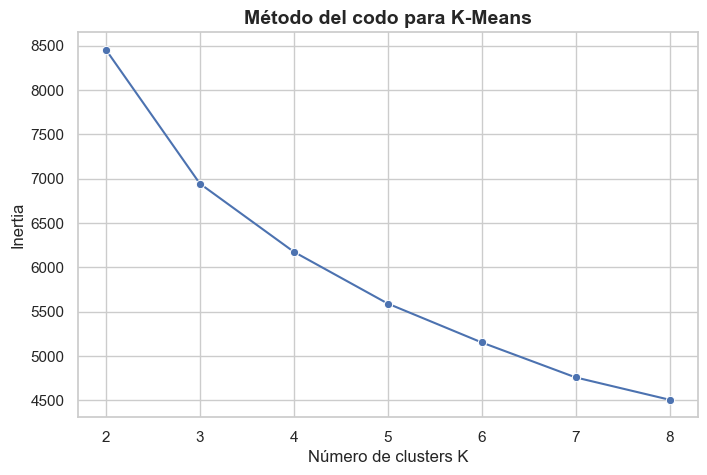

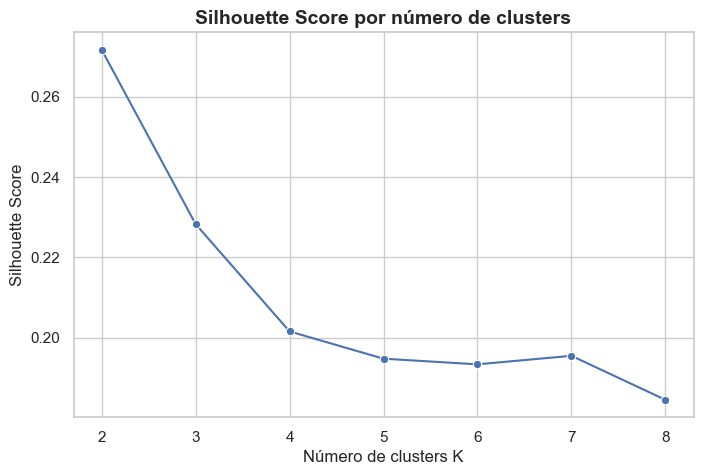

In [90]:
plt.figure(figsize=(8, 5))
sns.lineplot(data=cluster_metrics_df, x="k", y="inertia", marker="o")
plt.title("Método del codo para K-Means", fontsize=14, fontweight="bold")
plt.xlabel("Número de clusters K")
plt.ylabel("Inertia")
plt.show()

plt.figure(figsize=(8, 5))
sns.lineplot(data=cluster_metrics_df, x="k", y="silhouette_score", marker="o")
plt.title("Silhouette Score por número de clusters", fontsize=14, fontweight="bold")
plt.xlabel("Número de clusters K")
plt.ylabel("Silhouette Score")
plt.show()

In [91]:
# ============================================
# ENTRENAMIENTO FINAL DE K-MEANS
# ============================================

best_k = int(
    cluster_metrics_df
    .sort_values("silhouette_score", ascending=False)
    .iloc[0]["k"]
)

kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)

cluster_labels = kmeans_final.fit_predict(X_cluster_scaled)

spotify["cluster"] = cluster_labels.astype(str)

silhouette_final = silhouette_score(X_cluster_scaled, cluster_labels)

print(f"K seleccionado según Silhouette Score: {best_k}")
print(f"Silhouette Score final: {silhouette_final:.4f}")

K seleccionado según Silhouette Score: 2
Silhouette Score final: 0.2716


In [92]:
# ============================================
# PERFILAMIENTO DE CLUSTERS
# ============================================

cluster_profile = (
    spotify
    .groupby("cluster")
    .agg(
        total_canciones=("title", "count"),
        popularity_promedio=("popularity", "mean"),
        popularity_mediana=("popularity", "median"),
        energy_promedio=("energy", "mean"),
        danceability_promedio=("danceability", "mean"),
        loudness_promedio=("loudness_db", "mean"),
        valence_promedio=("valence", "mean"),
        acousticness_promedio=("acousticness", "mean"),
        year_promedio=("year", "mean")
    )
    .reset_index()
)

display(cluster_profile)

,cluster,total_canciones,popularity_promedio,popularity_mediana,energy_promedio,danceability_promedio,loudness_promedio,valence_promedio,acousticness_promedio,year_promedio
0,0,1248,60.636218,63.0,73.076122,56.607372,-7.280449,57.676282,13.580929,1995.558494
1,1,746,57.670241,59.0,37.268097,47.601877,-11.899464,35.577748,54.415550,1988.701072


In [93]:
# ============================================
# NOMBRES INTERPRETABLES PARA CLUSTERS
# ============================================

energy_median = cluster_profile["energy_promedio"].median()
dance_median = cluster_profile["danceability_promedio"].median()
valence_median = cluster_profile["valence_promedio"].median()
acoustic_median = cluster_profile["acousticness_promedio"].median()

def nombrar_cluster(row):
    if row["energy_promedio"] >= energy_median and row["danceability_promedio"] >= dance_median:
        return "Vibe energética bailable"
    elif row["acousticness_promedio"] >= acoustic_median and row["energy_promedio"] < energy_median:
        return "Vibe acústica suave"
    elif row["valence_promedio"] >= valence_median:
        return "Vibe positiva melódica"
    else:
        return "Vibe alternativa de nicho"

cluster_profile["cluster_name"] = cluster_profile.apply(nombrar_cluster, axis=1)

cluster_name_map = dict(zip(cluster_profile["cluster"], cluster_profile["cluster_name"]))

spotify["cluster_name"] = spotify["cluster"].map(cluster_name_map)

display(cluster_profile)

,cluster,total_canciones,popularity_promedio,popularity_mediana,energy_promedio,danceability_promedio,loudness_promedio,valence_promedio,acousticness_promedio,year_promedio,cluster_name
0,0,1248,60.636218,63.0,73.076122,56.607372,-7.280449,57.676282,13.580929,1995.558494,Vibe energética bailable
1,1,746,57.670241,59.0,37.268097,47.601877,-11.899464,35.577748,54.415550,1988.701072,Vibe acústica suave


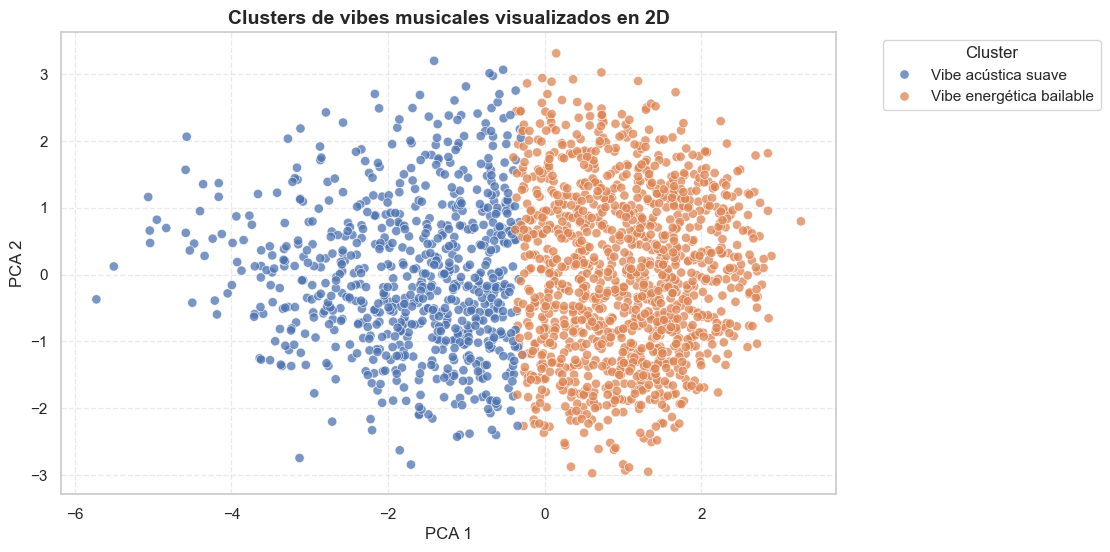

In [94]:
# ============================================
# PCA PARA VISUALIZACIÓN 2D
# ============================================

pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(X_cluster_scaled)

spotify["pca_1"] = pca_components[:, 0]
spotify["pca_2"] = pca_components[:, 1]

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=spotify,
    x="pca_1",
    y="pca_2",
    hue="cluster_name",
    alpha=0.75,
    s=45
)

plt.title("Clusters de vibes musicales visualizados en 2D", fontsize=14, fontweight="bold")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

## Visualización complementaria de clusters

Además de la visualización PCA en 2D, se incluye un `pairplot` para observar cómo se separan los clusters en variables musicales clave.

Esta visualización no crea un nuevo modelo: utiliza los clusters ya generados con K-Means y seleccionados mediante Silhouette Score.

El objetivo es revisar visualmente si los grupos tienen diferencias interpretables en variables como año, energía, bailabilidad, volumen y popularidad.

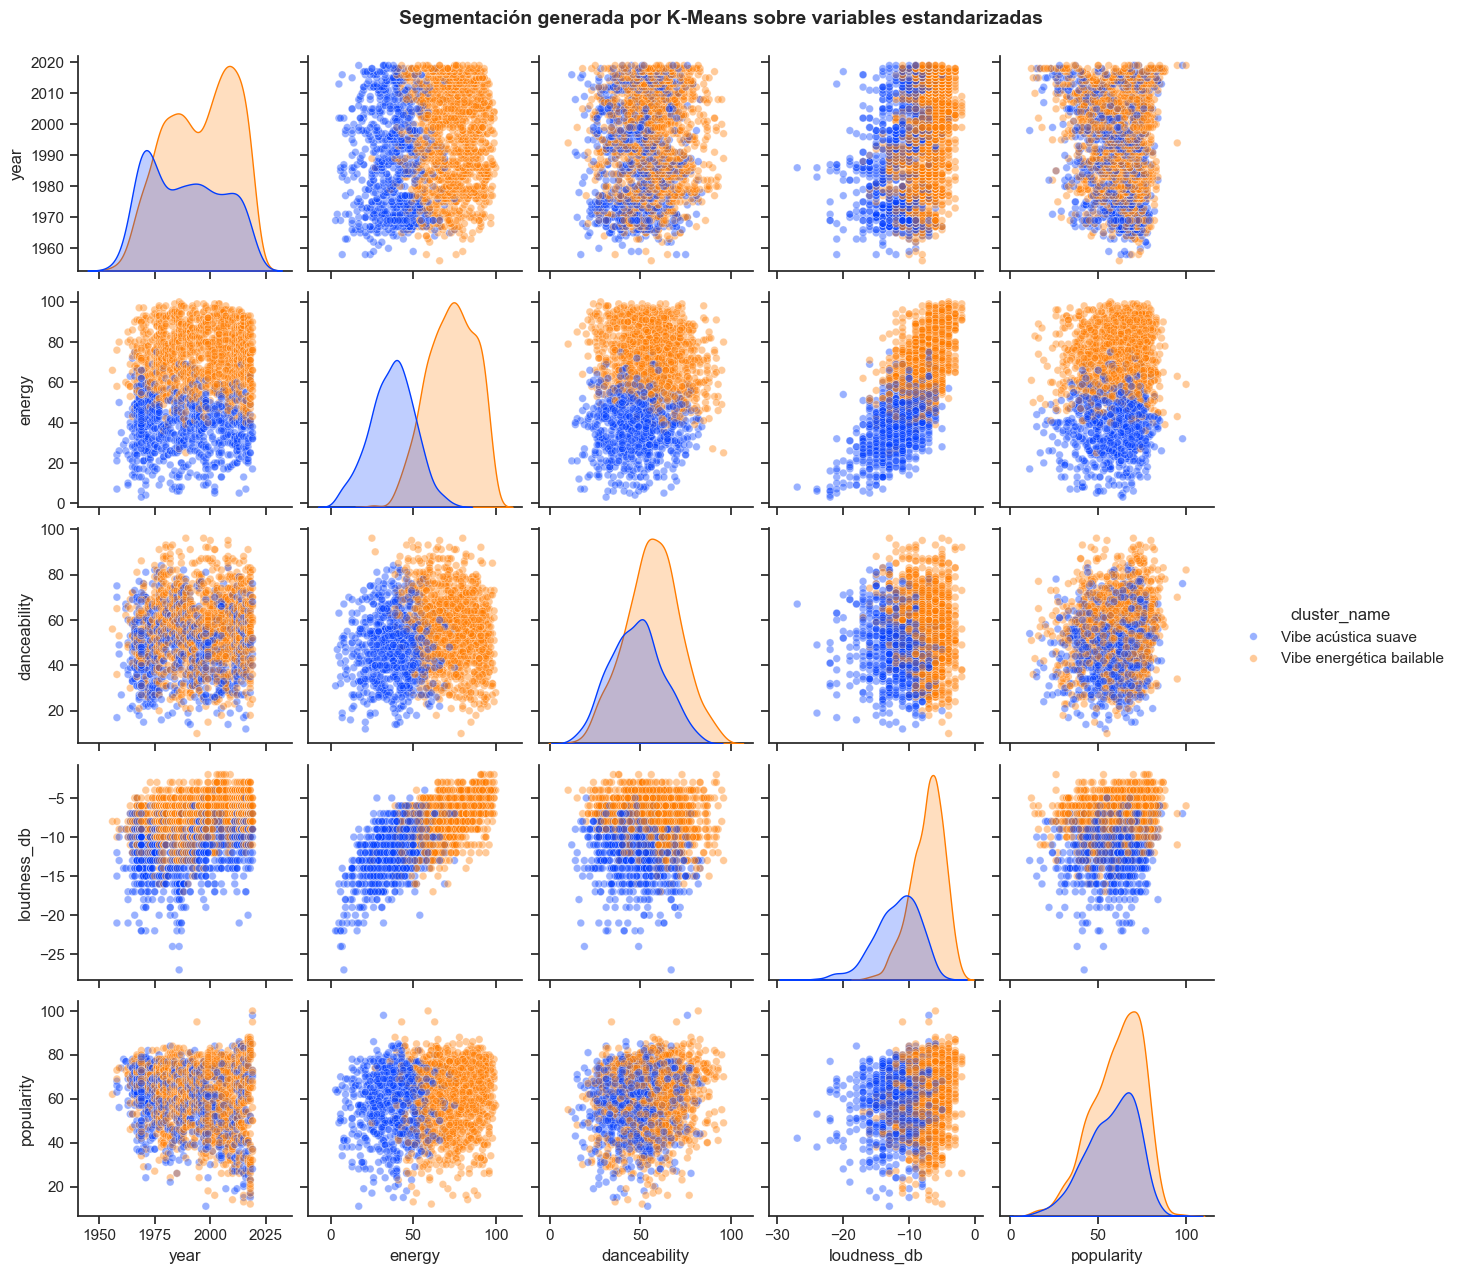

In [95]:
# ============================================
# PAIRPLOT DE VARIABLES CLAVE SEGÚN CLUSTER FINAL
# ============================================

variables_interes_pairplot = [
    "year",
    "energy",
    "danceability",
    "loudness_db",
    "popularity",
    "cluster_name"
]

variables_existentes_pairplot = [
    col for col in variables_interes_pairplot if col in spotify.columns
]

sns.set_theme(style="ticks")

pairgrid = sns.pairplot(
    data=spotify[variables_existentes_pairplot],
    hue="cluster_name",
    palette="bright",
    diag_kind="kde",
    plot_kws={"alpha": 0.4, "s": 30}
)

plt.suptitle(
    "Segmentación generada por K-Means sobre variables estandarizadas",
    y=1.02,
    fontsize=14,
    fontweight="bold"
)

plt.show()

### Interpretación del pairplot

El pairplot permite revisar si los clusters muestran diferencias visibles en variables musicales clave.

Esta visualización es útil como diagnóstico exploratorio, pero la visualización principal para el dashboard será el gráfico PCA 2D, porque resume la estructura de clusters en dos dimensiones y es más fácil de interpretar en Tableau.

=== TABLA DE CARGAS (LOADINGS) DEL PCA ===


,PCA 1,PCA 2
year,0.183344,-0.445885
energy,0.572024,-0.081776
danceability,0.229097,0.560390
loudness_db,0.495371,-0.321631
valence,0.330718,0.607916
acousticness,-0.481581,0.086337


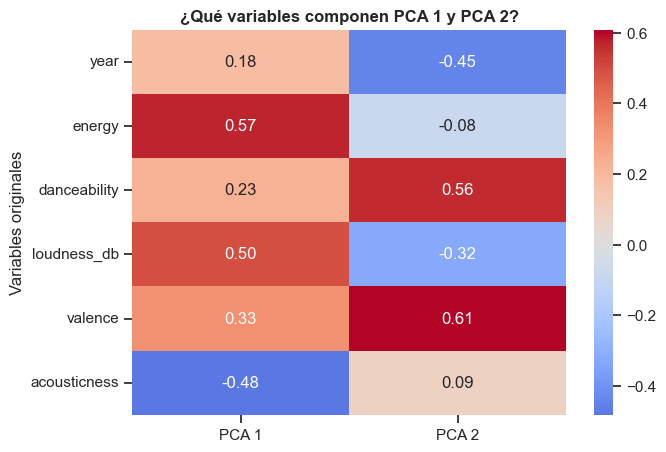

In [96]:
# ============================================
# LOADINGS DE PCA PARA INTERPRETACIÓN
# ============================================

pca_loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PCA 1", "PCA 2"],
    index=cluster_features
)

print("=== TABLA DE CARGAS (LOADINGS) DEL PCA ===")
display(pca_loadings)

plt.figure(figsize=(7, 5))

sns.heatmap(
    pca_loadings,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    cbar=True
)

plt.title("¿Qué variables componen PCA 1 y PCA 2?", fontsize=12, fontweight="bold")
plt.ylabel("Variables originales")
plt.show()

### Hallazgo de clustering

El catálogo no debe gestionarse como una lista homogénea de canciones.

K-Means permite organizarlo por vibes musicales interpretables. Esto ayuda a diseñar playlists premium por experiencia:

- playlists energéticas,
- playlists acústicas,
- playlists positivas,
- playlists alternativas o de nicho.

### Decisión de negocio

Los clusters con mayor `popularity_promedio`, suficiente volumen y baja tasa de zona crítica son mejores candidatos para playlists premium.

In [97]:
# ============================================
# INTEGRACIÓN DE CLUSTERS CON DATASET SPOTIFY + GRAMMY
# ============================================

cluster_cols = spotify[["title", "artist", "cluster", "cluster_name", "pca_1", "pca_2"]].copy()

spotify_grammy = spotify_grammy.drop(
    columns=[col for col in ["cluster", "cluster_name", "pca_1", "pca_2"] if col in spotify_grammy.columns],
    errors="ignore"
)

spotify_grammy = spotify_grammy.merge(
    cluster_cols,
    on=["title", "artist"],
    how="left"
)

cluster_grammy_summary = (
    spotify_grammy
    .groupby("cluster_name")
    .agg(
        total_canciones=("title", "count"),
        popularity_promedio=("popularity", "mean"),
        tasa_premium_pct=("popularity", lambda x: (x >= 72).mean() * 100),
        tasa_zona_critica_pct=("popularity", lambda x: (x <= 49).mean() * 100),
        canciones_artistas_grammy=("artist_has_grammy_record", "sum"),
        porcentaje_artistas_grammy=("artist_has_grammy_record", lambda x: x.mean() * 100)
    )
    .reset_index()
    .sort_values("popularity_promedio", ascending=False)
)

display(cluster_grammy_summary)

,cluster_name,total_canciones,popularity_promedio,tasa_premium_pct,tasa_zona_critica_pct,canciones_artistas_grammy,porcentaje_artistas_grammy
1,Vibe energética bailable,1248,60.636218,26.522436,23.157051,539,43.189103
0,Vibe acústica suave,746,57.670241,17.024129,28.150134,329,44.101877


# 12. Preparación de insumos para dashboard en Tableau

El dashboard interactivo será desarrollado en Tableau como entregable independiente por el equipo.

Desde este notebook se exportan las tablas procesadas necesarias para construirlo, asegurando coherencia entre el análisis exploratorio, el modelo, los clusters y la visualización ejecutiva.

El dashboard debe incluir como mínimo:

1. KPIs ejecutivos del catálogo.
2. Top canciones candidatas premium.
3. Matriz de géneros: Popularity vs volumen.
4. Popularity por década.
5. Clusters de vibes musicales en 2D.
6. Comparación entre canciones de artistas con y sin historial Grammy.

Cada visual debe responder una pregunta de negocio y apoyar una decisión concreta. No se incluyen gráficos decorativos.

In [98]:
# ============================================
# EXPORTACIÓN DE INSUMOS PARA TABLEAU
# ============================================

os.makedirs("data/dashboard", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)

premium_songs = (
    spotify_grammy
    .query("popularity >= 72")
    .sort_values("popularity", ascending=False)
    [
        [
            "title",
            "artist",
            "top_genre",
            "year",
            "decade",
            "popularity",
            "artist_has_grammy_record",
            "cluster_name",
            "pca_1",
            "pca_2"
        ]
    ]
)

segmentos.to_csv("data/dashboard/segmentos_popularity.csv", index=False)
quartile_summary.to_csv("data/dashboard/popularity_quartiles.csv", index=False)
decade_summary.to_csv("data/dashboard/popularity_decade.csv", index=False)
genre_summary.to_csv("data/dashboard/genre_summary_full.csv", index=False)
genre_summary_filtrado.to_csv("data/dashboard/genre_summary_filtered.csv", index=False)
artist_grammy_comparison.to_csv("data/dashboard/grammy_artist_comparison.csv", index=False)
genre_grammy_summary.to_csv("data/dashboard/genre_grammy_summary.csv", index=False)
cluster_profile.to_csv("data/dashboard/cluster_profile.csv", index=False)
cluster_grammy_summary.to_csv("data/dashboard/cluster_grammy_summary.csv", index=False)
premium_songs.to_csv("data/dashboard/premium_songs_candidates.csv", index=False)

# Export opcional para explicar PCA en presentación o documentación técnica
pca_loadings.to_csv("data/dashboard/pca_loadings.csv", index=True)

spotify_grammy.to_csv("data/processed/spotify_grammy_integrated.csv", index=False)
spotify.to_csv("data/processed/spotify_clustered.csv", index=False)

print("Tablas exportadas correctamente para Tableau.")

Tablas exportadas correctamente para Tableau.


# 13. Diseño sugerido del dashboard en Tableau

El dashboard se construirá fuera del notebook en Tableau. Esta sección documenta qué debe mostrar para mantener coherencia con el análisis.

## Visuales recomendados

**1. KPIs ejecutivos**  
Pregunta: ¿Cuál es el estado general del catálogo?  
Decisión: identificar volumen total, Popularity promedio, % premium y % zona crítica.

**2. Top canciones candidatas premium**  
Pregunta: ¿Cuáles son las canciones más fuertes del catálogo?  
Decisión: usarlas como candidatas iniciales para playlists premium.

**3. Matriz género: Popularity vs volumen**  
Pregunta: ¿Qué géneros combinan alto rendimiento y suficiente volumen?  
Decisión: priorizar géneros para playlists premium y campañas.

**4. Popularity por década**  
Pregunta: ¿Qué décadas funcionan mejor?  
Decisión: equilibrar catálogo reciente e histórico.

**5. Clusters de vibes musicales en 2D**  
Pregunta: ¿Qué perfiles musicales existen dentro del catálogo?  
Decisión: crear playlists premium por vibe musical.  
Campos clave: `pca_1`, `pca_2`, `cluster_name`.

**6. Grammy vs No Grammy**  
Pregunta: ¿El historial Grammy del artista se asocia con mayor Popularity?  
Decisión: usar Grammy como señal secundaria de prestigio.

## Filtros recomendados

- `top_genre`
- `decade`
- `cluster_name`
- `artist_has_grammy_record`

# 14. Candidatas premium

A partir del análisis, las canciones con `popularity >= 72` se consideran candidatas iniciales para playlists premium.

Esta lista no debe usarse de forma automática: debe combinarse con género, década, cluster musical e historial Grammy.

La decisión final no debe ser simplemente elegir las canciones más populares, sino priorizar aquellas que combinen:

- alto rendimiento,
- coherencia con géneros fuertes,
- pertenencia a clusters con buen desempeño,
- y señales externas de prestigio cuando existan.

Esta tabla también puede alimentar el visual de Top 20 canciones candidatas premium en Tableau.

In [99]:
# ============================================
# TOP 20 CANCIONES CANDIDATAS PREMIUM
# ============================================

premium_songs.head(20)

,title,artist,top_genre,year,decade,popularity,artist_has_grammy_record,cluster_name,pca_1,pca_2
793,dance monkey,tones and i,australian pop,2019,2010s,100,False,Vibe energética bailable,0.471055,0.226057
787,memories,maroon 5,pop,2019,2010s,98,True,Vibe acústica suave,-0.620862,0.386276
1641,all i want for christmas is you,mariah carey,dance pop,1994,1990s,95,True,Vibe energética bailable,0.104608,-1.310442
786,bad guy,billie eilish,electropop,2019,2010s,95,True,Vibe energética bailable,-0.136185,0.303079
688,believer,imagine dragons,modern rock,2017,2010s,88,True,Vibe energética bailable,2.409897,0.092675
726,shallow,lady gaga,dance pop,2018,2010s,88,True,Vibe energética bailable,-0.151563,-1.145274
745,high hopes,panic! at the disco,baroque pop,2018,2010s,87,False,Vibe energética bailable,2.365942,-0.734600
683,perfect,ed sheeran,pop,2017,2010s,87,True,Vibe energética bailable,0.185860,-1.459646
687,shape of you,ed sheeran,pop,2017,2010s,87,True,Vibe energética bailable,1.767231,1.025831
529,all of me,john legend,neo mellow,2013,2010s,86,True,Vibe acústica suave,-1.803831,-1.230233


# 15. Conclusiones finales

## Hallazgos principales

1. El catálogo no tiene un rendimiento uniforme: existen canciones en zona crítica, rendimiento medio y potencial premium.

2. El cuartil superior de Popularity funciona como benchmark inicial para playlists premium.

3. El género por sí solo no es suficiente para decidir, porque el catálogo tiene una distribución de cola larga. Se debe combinar Popularity promedio con volumen de canciones.

4. Los atributos acústicos no explican por sí solos la Popularity, pero sí son útiles para construir clusters de vibes musicales.

5. La Popularity varía por década, por lo que el catálogo premium debe equilibrar música reciente con clásicos de alto rendimiento.

6. El historial Grammy del artista funciona como señal secundaria de prestigio, pero no debe reemplazar el Popularity Score.

7. El modelo de regresión ayuda a estimar Popularity, aunque su capacidad predictiva está limitada por factores externos no presentes en el dataset.

8. K-Means permite organizar el catálogo en perfiles musicales interpretables para diseñar playlists premium por experiencia.

9. La visualización PCA 2D resume los clusters de forma apta para Tableau, mientras que el pairplot y el heatmap de loadings PCA ayudan a interpretar técnicamente cómo se separan los grupos.

## Recomendación ejecutiva

La plataforma debería priorizar canciones que combinen:

- alto `Popularity Score`,
- pertenencia al cuartil superior,
- género con buen rendimiento y volumen suficiente,
- pertenencia a un cluster musical con alta Popularity promedio y perfil interpretable,
- década alineada con la estrategia editorial,
- e historial Grammy como señal complementaria.

## Limitaciones

- `Popularity` puede cambiar con el tiempo.
- El dataset contiene cerca de 2.000 canciones y no representa todo el mercado musical.
- El cruce con Grammy se realizó principalmente a nivel artista, no a nivel exacto de canción.
- Correlación no implica causalidad.
- El modelo predictivo no reemplaza la curaduría humana ni el criterio editorial.
- Los clusters dependen de las variables seleccionadas y del escalamiento aplicado.

## Próximos pasos

- Validar playlists premium con datos reales de reproducciones, skips, likes y retención.
- Medir impacto con A/B testing.
- Incorporar datos de usuarios y comportamiento de escucha.
- Actualizar el modelo con datos recientes.
- Evaluar si los clusters se mantienen estables con catálogos más grandes o datos actualizados.

In [100]:
# ============================================
# RESUMEN FINAL DEL PROYECTO
# ============================================

print("=" * 80)
print("RESUMEN FINAL — SPOTIFY STREAMING AUDIT")
print("=" * 80)

print(f"Total de canciones analizadas: {total_canciones}")
print(f"Popularity promedio del catálogo: {popularity_promedio:.2f}")
print(f"Canciones en zona crítica: {canciones_zona_critica} ({tasa_zona_critica:.1f}%)")
print(f"Canciones con potencial premium: {canciones_premium} ({tasa_premium:.1f}%)")

print("-" * 80)
print("MODELO PREDICTIVO")
print(f"Mejor modelo: {best_model_name}")
print(f"RMSE: {best_rmse:.3f}")
print(f"MAE: {best_mae:.3f}")
print(f"R²: {best_r2:.3f}")
print("Modelo exportado: models/best_popularity_model.joblib")

print("-" * 80)
print("CLUSTERING")
print(f"K seleccionado: {best_k}")
print(f"Silhouette Score final: {silhouette_final:.4f}")
print("Dataset con clusters: data/processed/spotify_clustered.csv")

print("-" * 80)
print("INSUMOS PARA TABLEAU")
print("Tablas exportadas en: data/dashboard/")
print("Dataset integrado Spotify + Grammy: data/processed/spotify_grammy_integrated.csv")
print("Loadings PCA para documentación técnica: data/dashboard/pca_loadings.csv")

print("=" * 80)
print("Notebook ejecutado correctamente y preparado como insumo para dashboard, pitch y GitHub.")
print("=" * 80)

RESUMEN FINAL — SPOTIFY STREAMING AUDIT
Total de canciones analizadas: 1994
Popularity promedio del catálogo: 59.53
Canciones en zona crítica: 499 (25.0%)
Canciones con potencial premium: 458 (23.0%)
--------------------------------------------------------------------------------
MODELO PREDICTIVO
Mejor modelo: Random Forest
RMSE: 14.253
MAE: 11.527
R²: 0.054
Modelo exportado: models/best_popularity_model.joblib
--------------------------------------------------------------------------------
CLUSTERING
K seleccionado: 2
Silhouette Score final: 0.2716
Dataset con clusters: data/processed/spotify_clustered.csv
--------------------------------------------------------------------------------
INSUMOS PARA TABLEAU
Tablas exportadas en: data/dashboard/
Dataset integrado Spotify + Grammy: data/processed/spotify_grammy_integrated.csv
Loadings PCA para documentación técnica: data/dashboard/pca_loadings.csv
Notebook ejecutado correctamente y preparado como insumo para dashboard, pitch y GitHub.
